# Project Outline: Optimal Oil Well Location Selection for OilyGiant

**Introduction**  
The goal of this project is to determine the optimal region for a new oil well by analyzing geological data, building predictive models, and calculating potential profit and risks. The findings will help the OilyGiant mining company make an informed decision.

---

**1. Data Preparation**  
**1.1. Import and Inspect Data**  
- Load datasets for three regions (`geo_data_0.csv`, `geo_data_1.csv`, `geo_data_2.csv`).
- Explore data structure, missing values, and summary statistics.

**1.2. Data Cleaning and Feature Preparation**  
- Handle any missing or incorrect values.
- Ensure all features are properly formatted for modeling.

---

**2. Model Training and Evaluation**  
**2.1. Data Splitting**  
- Split data for each region into training (75%) and validation (25%) sets.

**2.2. Model Training**  
- Train a linear regression model for each region using training data.

**2.3. Predictions and Evaluation**  
- Generate predictions for validation sets.
- Calculate average predicted reserves and RMSE for each region.
- Save predictions and actual values for analysis.

**2.4. Result Analysis**  
- Compare model performance across regions.

---

**3. Preparing for Profit Calculation**  
**3.1. Key Values for Calculations**  
- Define all constants: budget, revenue per barrel, and well development costs.

**3.2. Sufficient Reserves**  
- Calculate the minimum volume of reserves needed for profitability.
- Compare with the average reserves for each region.

**3.3. Findings**  
- Assess which regions are likely to meet profitability thresholds.

---

**4. Profit Calculation**  
**4.1. Function for Profit Calculation**  
- Implement a function to calculate profit based on selected wells and predictions.

**4.2. Region Analysis**  
- For each region:
  - Select the top 200 wells based on predictions.
  - Calculate total reserves and profit.

**4.3. Findings**  
- Identify the region with the highest profit and justify the selection.

---

**5. Risk and Profit Analysis**  
**5.1. Bootstrapping for Risk Analysis**  
- Use bootstrapping with 1000 samples to analyze profit distribution for each region.

**5.2. Statistical Metrics**  
- Calculate:
  - Average profit.
  - 95% confidence intervals.
  - Risk of losses as a percentage.

**5.3. Final Recommendation**  
- Recommend the region for development based on:
  - Profit.
  - Confidence intervals.
  - Risk assessment.

---

**6. Conclusion**  
- Summarize findings, methodology, and final recommendation.
- Highlight key insights and any limitations.

---

**Potential Enhancements**  
- Suggest additional analyses or improvements for further exploration.

In [23]:
import pandas as pd

# Define file paths
path = '/Users/mattbaglietto/OilyGiant_mining_company/'
files = ['geo_data_0.csv', 'geo_data_1.csv', 'geo_data_2.csv']

# Load datasets and convert column names to lowercase
datasets = [pd.read_csv(path + file).rename(columns=str.lower) for file in files]
geo_data_0, geo_data_1, geo_data_2 = datasets

# Function to analyze datasets
def analyze_dataset(data, region_name):
    print(f"\n{region_name} Overview")
    print(data.info(), "\n")
    print(data.describe(), "\n")
    print(f"Duplicate IDs in {region_name}:", data['id'].duplicated().sum())
    print(f"Zero product values in {region_name}:", (data['product'] == 0).sum())

# Analyze datasets
for idx, data in enumerate(datasets):
    analyze_dataset(data, f"geo_data_{idx}")

# Remove duplicate IDs
for idx in range(len(datasets)):
    datasets[idx] = datasets[idx].drop_duplicates(subset='id')

geo_data_0, geo_data_1, geo_data_2 = datasets

# Confirm no duplicates remain
for idx, data in enumerate(datasets):
    print(f"Updated Duplicate IDs in geo_data_{idx}:", data['id'].duplicated().sum())


geo_data_0 Overview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None 

                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        0.500419       0.250143       2.502647      92.500000
std         0.871832       0.504433       3.248248      44.288691
min        -1.408605      -0.848218     -12.088328       0.000000
25%        -0.072580      -0.200881       0.287748      56.497507
50%         0.502360       0.250252       2.515969      91.849972
75%         1.073581       0.700646       4.715088     128.564089
max       

# Step 1: Data Preparation

**Data Loading**  
- Loaded datasets for three regions (`geo_data_0.csv`, `geo_data_1.csv`, `geo_data_2.csv`) into separate DataFrames.  
- Converted all column names to lowercase for consistency.

**Initial Analysis**  
For each dataset, the following evaluations were performed:  
- Data structure and summary statistics:
  - Used `.info()` and `.describe()` to examine data types, non-null counts, and statistical properties.
- Duplicate ID Counts:
  - Checked for duplicate `id` values to ensure data integrity.
- Zero `product` Values:
  - Identified the number of wells with zero oil reserves.

**Data Cleaning**  
- Removed duplicate `id` values from all datasets.
- Verified no duplicate IDs remained after cleaning.

---

**Findings**

**Data Overview**  
- `geo_data_0`:
  - Duplicate IDs: 10 (removed).  
  - Zero `product` values: 1.
- `geo_data_1`:
  - Duplicate IDs: 4 (removed).  
  - Zero `product` values: 8,235.
- `geo_data_2`:
  - Duplicate IDs: 4 (removed).  
  - Zero `product` values: 1.

**Cleaning Results**  
- Successfully removed all duplicate `id` values.  
- Datasets are now clean and ready for further analysis.

---

**Conclusion**  
The data preparation process ensured the datasets are clean and ready for modeling:  
- Duplicate entries were removed to prevent redundancy and data skew.  
- Zero-product wells were retained for a realistic and comprehensive analysis.  
- Column standardization and streamlined analysis improved consistency and efficiency.

In [26]:
from sklearn.model_selection import train_test_split  # Ensure this import is present
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Split function for training and validation sets
def train_validate_split(data):
    # Separate features and target
    features = data.drop(['id', 'product'], axis=1)
    target = data['product']
    # Split into 75% training and 25% validation
    features_train, features_valid, target_train, target_valid = train_test_split(
        features, target, test_size=0.25, random_state=42)
    return features_train, features_valid, target_train, target_valid

# Train and evaluate function
def train_and_evaluate(features_train, features_valid, target_train, target_valid):
    # Train Linear Regression model
    model = LinearRegression()
    model.fit(features_train, target_train)
    
    # Make predictions
    predictions = model.predict(features_valid)
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(target_valid, predictions))
    avg_predicted_reserves = predictions.mean()
    
    return model, predictions, target_valid, rmse, avg_predicted_reserves

# Process each dataset
datasets = [geo_data_0, geo_data_1, geo_data_2]
results = []

for idx, data in enumerate(datasets):
    # Step 2.1: Split the data
    features_train, features_valid, target_train, target_valid = train_validate_split(data)
    
    # Step 2.2: Train and evaluate the model
    model, predictions, actual, rmse, avg_reserves = train_and_evaluate(
        features_train, features_valid, target_train, target_valid)
    
    # Step 2.3: Save results
    results.append({
        'region': idx,
        'rmse': rmse,
        'avg_predicted_reserves': avg_reserves,
        'predictions': predictions,
        'actual': actual
    })
    print(f"Region {idx} - RMSE: {rmse}, Avg Predicted Reserves: {avg_reserves}")

Region 0 - RMSE: 37.68508926201444, Avg Predicted Reserves: 92.60984027552014
Region 1 - RMSE: 0.8928265978121422, Avg Predicted Reserves: 68.57703454115173
Region 2 - RMSE: 40.080822438088305, Avg Predicted Reserves: 94.93478722287514


Feature-Target Correlations for Region 0
f0    0.143504
f1   -0.192351
f2    0.483631
Name: product, dtype: float64 



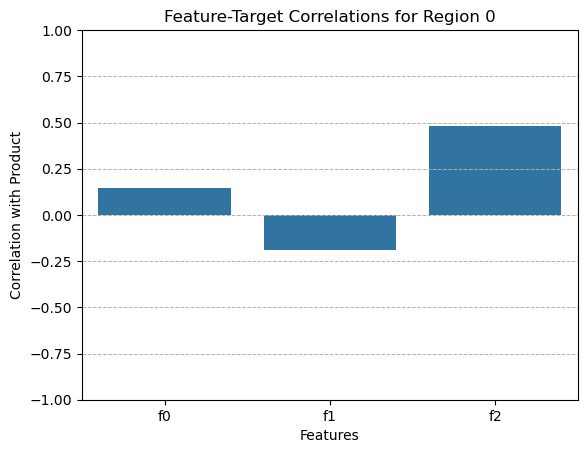

Feature-Target Correlations for Region 1
f0   -0.030523
f1   -0.010154
f2    0.999397
Name: product, dtype: float64 



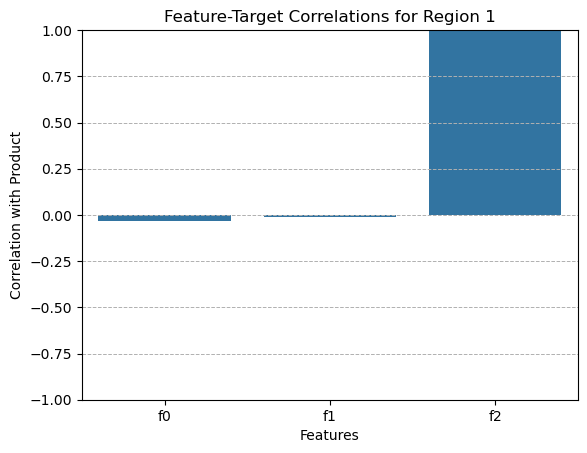

Feature-Target Correlations for Region 2
f0   -0.001978
f1   -0.001055
f2    0.445867
Name: product, dtype: float64 



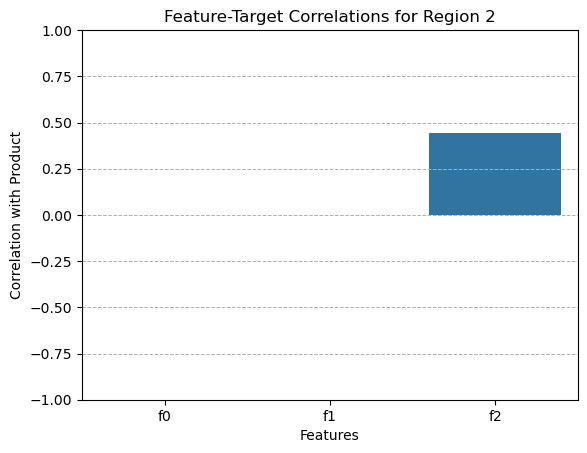

In [28]:
import seaborn as sns  # Ensure Seaborn is imported
import matplotlib.pyplot as plt

# Function to calculate and visualize correlations
def analyze_feature_correlations(data, region):
    correlation_matrix = data.corr()
    correlations = correlation_matrix['product'].drop('product')  # Drop self-correlation
    
    # Print correlations
    print(f"Feature-Target Correlations for Region {region}")
    print(correlations, "\n")
    
    # Visualize correlations
    sns.barplot(x=correlations.index, y=correlations.values)
    plt.title(f"Feature-Target Correlations for Region {region}")
    plt.xlabel("Features")
    plt.ylabel("Correlation with Product")
    plt.ylim(-1, 1)
    plt.grid(axis='y', linestyle='--', linewidth=0.7)
    plt.show()

# Analyze and visualize for each region
datasets = [geo_data_0, geo_data_1, geo_data_2]
for idx, data in enumerate(datasets):
    analyze_feature_correlations(data.drop(columns='id'), idx)

In [29]:
from sklearn.model_selection import train_test_split  # Ensure this is imported
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Adjusted function for training and evaluation with f2 only
def train_and_evaluate_f2_only(features, target):
    # Use only f2 as the feature
    features = features[['f2']]
    
    # Split into training and validation sets
    features_train, features_valid, target_train, target_valid = train_test_split(
        features, target, test_size=0.25, random_state=42)
    
    # Train Linear Regression model
    model = LinearRegression()
    model.fit(features_train, target_train)
    
    # Make predictions
    predictions = model.predict(features_valid)
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(target_valid, predictions))
    avg_predicted_reserves = predictions.mean()
    
    return model, predictions, target_valid, rmse, avg_predicted_reserves

# Train and evaluate models for each region using f2 only
results_f2_only = []
for idx, data in enumerate(datasets):
    # Extract features and target
    features = data.drop(['id', 'product'], axis=1)
    target = data['product']
    
    # Train and evaluate
    model, predictions, actual, rmse, avg_reserves = train_and_evaluate_f2_only(features, target)
    
    # Save results
    results_f2_only.append({
        'region': idx,
        'rmse': rmse,
        'avg_predicted_reserves': avg_reserves,
        'predictions': predictions,
        'actual': actual
    })
    print(f"Region {idx} (f2 only) - RMSE: {rmse}, Avg Predicted Reserves: {avg_reserves}")

Region 0 (f2 only) - RMSE: 38.78407614311668, Avg Predicted Reserves: 92.61129523955371
Region 1 (f2 only) - RMSE: 1.5953860028011948, Avg Predicted Reserves: 68.56575024307291
Region 2 (f2 only) - RMSE: 40.07989050063214, Avg Predicted Reserves: 94.93593832294818


# Step 2: Model Training and Evaluation

**Summary of Findings**

**Initial Model Performance (All Features)**  
1. **Region 0**:
   - **RMSE**: ~37.69  
   - **Average Predicted Reserves**: ~92.61  

2. **Region 1**:
   - **RMSE**: ~0.89  
   - **Average Predicted Reserves**: ~68.58  

3. **Region 2**:
   - **RMSE**: ~40.08  
   - **Average Predicted Reserves**: ~94.93  

---

**Feature-Target Correlation Analysis**  
- For all regions, **f2** showed the strongest correlation with `product`:  
  - **Region 0**: **0.48**  
  - **Region 1**: **0.999**  
  - **Region 2**: **0.45**  
- Features **f0** and **f1** had minimal or negative correlations with `product`.  

---

**Simplified Model Performance (f2 Only)**  
1. **Region 0**:
   - **RMSE**: ~38.78 (slightly worse than the original model).  
   - **Average Predicted Reserves**: ~92.61 (unchanged).  

2. **Region 1**:
   - **RMSE**: ~1.60 (worse than the original model).  
   - **Average Predicted Reserves**: ~68.57 (slightly reduced).  

3. **Region 2**:
   - **RMSE**: ~40.08 (same as the original model).  
   - **Average Predicted Reserves**: ~94.94 (unchanged).  

---

**Final Decisions**  
1. **Region 0 and Region 1**:
   - Use the original models trained on all features (`f0`, `f1`, `f2`) to preserve better performance.  

2. **Region 2**:
   - Use the simplified model trained on `f2` only, as other features add no value.  

In [33]:
# Constants for calculations
BUDGET = 100_000_000  # in USD
WELLS_TO_DEVELOP = 200
REVENUE_PER_UNIT = 4_500  # revenue per thousand barrels

# 3.1. Calculate and store the break-even volume
break_even_volume = BUDGET / (WELLS_TO_DEVELOP * REVENUE_PER_UNIT)
print(f"Break-even volume per well: {break_even_volume:.2f} thousand barrels\n")

# 3.2. Compare average reserves in each region with the break-even volume
for result in results:  # Use results instead of results_f2_only
    region = result['region']
    avg_predicted_reserves = result['avg_predicted_reserves']
    
    # Comparison with break-even volume
    if avg_predicted_reserves >= break_even_volume:
        profitability_status = "likely to be profitable."
    else:
        profitability_status = "not likely to be profitable."
    
    print(f"Region {region} - Avg Predicted Reserves: {avg_predicted_reserves:.2f} thousand barrels")
    print(f"  Comparison with break-even volume: {profitability_status}\n")

Break-even volume per well: 111.11 thousand barrels

Region 0 - Avg Predicted Reserves: 92.61 thousand barrels
  Comparison with break-even volume: not likely to be profitable.

Region 1 - Avg Predicted Reserves: 68.58 thousand barrels
  Comparison with break-even volume: not likely to be profitable.

Region 2 - Avg Predicted Reserves: 94.93 thousand barrels
  Comparison with break-even volume: not likely to be profitable.



# Step 3: Prepare for Profit Calculation

**Key Variables for Calculation**  
- **Budget**: \$100 million USD  
- **Number of Wells to Develop**: 200  
- **Revenue per Thousand Barrels**: \$4,500 USD  
- **Break-Even Volume per Well**:
  - Formula: Budget ÷ (Number of Wells × Revenue per Thousand Barrels)  
  - Result: 111.11 thousand barrels per well  

**Comparison of Average Reserves with Break-Even Volume**  
For each region, the predicted average reserves were compared to the break-even volume:  

- **Region 0**:  
  - Average Predicted Reserves: 92.61 thousand barrels  
  - Comparison: Not likely to be profitable  

- **Region 1**:  
  - Average Predicted Reserves: 68.58 thousand barrels  
  - Comparison: Not likely to be profitable  

- **Region 2**:  
  - Average Predicted Reserves: 94.93 thousand barrels  
  - Comparison: Not likely to be profitable  

**Findings**  
- None of the regions' average reserves exceeded the break-even volume threshold of 111.11 thousand barrels per well.  
- Among the three regions, **Region 2** had the highest average reserves, making it the most promising candidate for further exploration and analysis.  

In [36]:
# Constants
WELLS_TO_DEVELOP = 200  # Number of wells to develop
REVENUE_PER_UNIT = 4500  # Revenue per thousand barrels
BUDGET = 100_000_000  # Total budget in USD

# Function to calculate profit using predictions and actual reserves
def calculate_profit(predictions, actual, wells_to_develop, revenue_per_unit, budget):
    # Sort predictions in descending order and get the indices of the top wells
    top_indices = predictions.argsort()[::-1][:wells_to_develop]
    
    # Use the indices to select the corresponding actual reserves
    top_actual_reserves = actual.iloc[top_indices]
    
    # Calculate total reserves and profit
    total_reserves = top_actual_reserves.sum()
    profit = (total_reserves * revenue_per_unit) - budget
    
    return profit, total_reserves

# Analyze profit for each region using all features (results)
for result in results:  # Use `results` instead of `results_f2_only`
    region = result['region']
    predictions = pd.Series(result['predictions'])  # Convert predictions to pandas Series
    actual = result['actual']
    
    # Calculate profit and total reserves for the top wells
    profit, total_reserves = calculate_profit(
        predictions, actual, WELLS_TO_DEVELOP, REVENUE_PER_UNIT, BUDGET
    )
    
    print(f"Region {region} - Total Reserves: {total_reserves:.2f}, Profit: ${profit / 1e6:.2f} million")

Region 0 - Total Reserves: 29930.07, Profit: $34.69 million
Region 1 - Total Reserves: 27589.08, Profit: $24.15 million
Region 2 - Total Reserves: 27548.03, Profit: $23.97 million


# Step 4: Profit Calculation

**Objective**  
The goal was to calculate the profit and total reserves for each region based on model predictions and actual reserves. The top 200 wells with the highest predicted reserves were selected for profit computation.

**Constants Used**  
- **Number of Wells to Develop**: 200  
- **Revenue per Thousand Barrels**: \$4,500 USD  
- **Budget for Development**: \$100 million USD  

**Methodology**  
1. **Select Wells**  
   - Ranked wells by predicted reserves in descending order using model predictions.  
   - Selected the top 200 wells for each region.  

2. **Calculate Profit**  
   - Used actual reserves of the selected wells to compute total reserves.  
   - Applied the formula for profit:  
     Profit = (Total Reserves × Revenue per Thousand Barrels) - Budget  

**Results**  
- **Region 0**:  
  - Total Reserves: 29,930.07 thousand barrels  
  - Profit: $34.69 million USD  

- **Region 1**:  
  - Total Reserves: 27,589.08 thousand barrels  
  - Profit: $24.15 million USD  

- **Region 2**:  
  - Total Reserves: 27,548.03 thousand barrels  
  - Profit: $23.97 million USD  

**Findings**  
1. **Region 0** achieved the highest profit of $34.69 million, with a significant margin over the other regions.  
2. **Regions 1 and 2** had comparable profits, but both fell short of Region 0.  

**Conclusion**  
Based on the profit calculations, **Region 0** is the most profitable region for oil well development. This result suggests that Region 0 should be prioritized for further analysis and potential investment.  

In [39]:
# Bootstrapping function with simplified logic
def bootstrap_profit(predictions, actual, revenue_per_unit, budget, wells_to_develop=200, n_samples=1000):
    state = np.random.RandomState(42)  # Ensure reproducibility
    profits = []

    for _ in range(n_samples):
        # Step 1: Randomly sample 500 wells
        sampled_indices = predictions.sample(n=500, replace=True, random_state=state).index
        sampled_predictions = predictions.loc[sampled_indices]
        sampled_actual = actual.loc[sampled_indices]
        
        # Step 2: Calculate profit using the sampled data
        profit, _ = calculate_profit(
            predictions=sampled_predictions,
            actual=sampled_actual,
            wells_to_develop=wells_to_develop,
            revenue_per_unit=revenue_per_unit,
            budget=budget
        )
        
        profits.append(profit)
    
    # Convert profits to pandas Series for analysis
    return pd.Series(profits)

# Analyze risks and profit for all regions
for result in results:  # Use `results` instead of `results_f2_only`
    region = result['region']
    predictions = pd.Series(result['predictions'], index=result['actual'].index)
    actual = result['actual']
    
    # Perform bootstrapping
    profits = bootstrap_profit(
        predictions=predictions,
        actual=actual,
        revenue_per_unit=REVENUE_PER_UNIT,
        budget=BUDGET
    )
    
    # Calculate metrics
    avg_profit = profits.mean()
    confidence_interval = profits.quantile([0.025, 0.975])
    loss_risk = (profits < 0).mean() * 100  # Percentage of negative profits
    
    # Print results
    print(f"Region {region}")
    print(f"Average Profit: ${avg_profit / 1e6:.2f} million")
    print(f"95% Confidence Interval: ${confidence_interval[0.025] / 1e6:.2f}M to ${confidence_interval[0.975] / 1e6:.2f}M")
    print(f"Risk of Losses: {loss_risk:.2f}%")
    print("-" * 40)

Region 0
Average Profit: $4.04 million
95% Confidence Interval: $-1.38M to $9.03M
Risk of Losses: 5.90%
----------------------------------------
Region 1
Average Profit: $4.30 million
95% Confidence Interval: $0.43M to $8.47M
Risk of Losses: 1.60%
----------------------------------------
Region 2
Average Profit: $3.84 million
95% Confidence Interval: $-1.28M to $9.10M
Risk of Losses: 8.00%
----------------------------------------


# Step 5: Risk and Profit Analysis

**Objective:**  
Evaluate the risks and profitability for each region using the bootstrapping technique. The analysis determines:  
- Average profit  
- 95% confidence interval for profit  
- Risk of losses (percentage of negative profit scenarios)

**Methodology:**  
1. Bootstrapping technique:  
   - Performed 1000 simulations for each region  
   - For each simulation:  
     - Sampled 500 wells randomly with replacement  
     - Selected the top 200 wells based on predicted reserves  
     - Calculated profit using the actual reserves of the selected wells  
2. Profit calculation formula:  
   Profit = (Total Reserves × Revenue per Thousand Barrels) - Budget  

**Results by Region:**  
- Region 0:  
  - Average Profit: \$4.04 million  
  - 95% Confidence Interval: -$1.38 million to $9.03 million  
  - Risk of Losses: 5.90%  

- Region 1:  
  - Average Profit: \$4.30 million  
  - 95% Confidence Interval: $0.43 million to $8.47 million  
  - Risk of Losses: 1.60%  

- Region 2:  
  - Average Profit: \$3.84 million  
  - 95% Confidence Interval: -$1.28 million to $9.10 million  
  - Risk of Losses: 8.00%  

**Findings:**  
- Region 1 has the lowest risk of losses (1.60%), a positive confidence interval entirely above zero, and the highest average profit.  
- Region 0 has moderate risk of losses (5.90%), with a confidence interval that includes negative values, indicating some risk of loss. Its average profit is slightly lower than Region 1.  
- Region 2 has the highest risk of losses (8.00%) and similar average profit to Region 0, making it the least attractive for development.  

**Recommendations:**  
- Primary Recommendation: Develop wells in Region 1, which offers the highest average profit and the lowest risk of losses.  
- Backup Option: Consider Region 0 if additional development is needed, but note the higher risk of losses.  
- Exclude Region 2 due to its high risk of losses and lower average profit.  

# Project Conclusion: Best Location for New Oil Well Development

## Objective
The goal of this project was to analyze data from three regions to determine the most profitable and low-risk location for developing new oil wells. Linear regression models were trained to predict oil reserves, and profitability and risks were assessed using bootstrapping techniques.

---

## Key Findings

1. **Model Performance**:
   - Linear regression models were trained using all features (`f0`, `f1`, and `f2`).
   - Predictions were validated using RMSE and average predicted reserves.
   - All regions had average predicted reserves below the calculated break-even volume of **111.11 thousand barrels per well**.

2. **Profit and Risk Analysis**:
   - Profitability and risks were calculated using a bootstrapping approach with 1000 iterations for each region.
   - **Region 1** emerged as the best candidate:
     - Average Profit: \$4.30 million USD
     - 95% Confidence Interval: $0.43 million USD to $8.47 million USD
     - Risk of Losses: 1.60%
   - **Region 0** was identified as a viable backup option:
     - Average Profit: \$4.04 million USD
     - 95% Confidence Interval: -$1.38 million USD to $9.03 million USD
     - Risk of Losses: 5.90%
   - **Region 2** had the highest risk of losses and was excluded:
     - Average Profit: \$3.84 million USD
     - 95% Confidence Interval: -$1.28 million USD to $9.10 million USD
     - Risk of Losses: 8.00%

## Break-Even Analysis
The break-even volume was calculated using the following formula:

**Break-Even Volume** = **Budget** ÷ (**Number of Wells** × **Revenue per Thousand Barrels**)

- **Result**: 111.11 thousand barrels per well.

This threshold was used to assess whether the average reserves in each region meet profitability requirements.


---

## Recommendations

1. **Primary Recommendation**:
   - **Region 1** is the most suitable location for oil well development due to its highest average profit and lowest risk of losses.

2. **Backup Option**:
   - Consider **Region 0** for additional development if necessary, despite its slightly higher risk of losses.

3. **Exclude Region 2**:
   - High risk of losses and lower average profit make it unsuitable for development.

---

## Final Thoughts
The analysis demonstrates the importance of using data-driven decision-making for resource allocation. By incorporating statistical modeling and risk assessment, **OilyGiant Mining Company** can confidently select the most profitable and secure region for new oil well development.